<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/Concatenate_breast_cancer_image_calssification_effecientb3%5B1%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **IMPORT LIBRARIES**

In [ ]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image
import cv2
import numpy as np
import pandas as pd
# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
import torch
from torch.utils.data import DataLoader
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout,
    BatchNormalization, Input, GlobalAveragePooling2D, Concatenate, Resizing)

# Importing necessary functions

from tensorflow.keras.utils import array_to_img, img_to_array, load_img

import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


# **DATA PATHS WITH LABEL**

In [ ]:
# Generate data paths with labels
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)

In [ ]:
df

,filepaths,labels
0,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
1,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
2,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
3,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
4,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
...,...,...
1573,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1574,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1575,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1576,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant


In [ ]:
strat = df['labels']
train_df, test_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

In [ ]:
test_df

,filepaths,labels
133,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
481,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
372,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
605,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
571,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
...,...,...
1444,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1413,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
726,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
218,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal


# **BATCH NORMALIZATION**

In [ ]:
# crobed image size
batch_size = 8
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 1262 validated image filenames belonging to 3 classes.
Found 316 validated image filenames belonging to 3 classes.


In [ ]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer
# Input Layer
input_layer = Input(shape=img_shape)
# Pre-trained Models
efficientnet_b3 = tf.keras.applications.EfficientNetB3(include_top=False, weights="imagenet", input_shape=img_shape, pooling=None)
densenet201 = tf.keras.applications.DenseNet201(include_top=False, weights="imagenet", input_shape=img_shape, pooling=None)
resnet50 = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=img_shape, pooling=None)
nasnet_large = tf.keras.applications.NASNetLarge(include_top=False, weights="imagenet", input_shape=(331, 331, 3), pooling=None)
vgg16 = tf.keras.applications.VGG16(include_top=False, weights="imagenet", input_shape=img_shape, pooling=None)
nasnet_mobile = tf.keras.applications.NASNetMobile(include_top=False, weights="imagenet", input_shape=img_shape, pooling=None)

# Resize inputs for NASNetLarge (331x331 to match its requirement)
resized_input = Resizing(331, 331)(input_layer)

# Extract Features
efficientnet_features = GlobalAveragePooling2D()(efficientnet_b3(input_layer))
densenet_features = GlobalAveragePooling2D()(densenet201(input_layer))
resnet_features = GlobalAveragePooling2D()(resnet50(input_layer))
nasnet_large_features = GlobalAveragePooling2D()(nasnet_large(resized_input))
vgg_features = GlobalAveragePooling2D()(vgg16(input_layer))
nasnet_mobile_features = GlobalAveragePooling2D()(nasnet_mobile(input_layer))

# Concatenate Features
concatenated_features = Concatenate()([
    efficientnet_features,
    densenet_features,
    resnet_features,
    nasnet_large_features,
    vgg_features,
    nasnet_mobile_features
])
# Dense Layers for Classification
x = BatchNormalization()(concatenated_features)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006), bias_regularizer=regularizers.l1(0.006))(x)
x = Dropout(0.45)(x)
output_layer = Dense(class_count, activation='softmax')(x)
# Build model
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])



43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
343610240/343610240 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
epochs = 50   # number of all epochs in training

history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= test_gen,
                    validation_steps= None, shuffle= True)

Epoch 1/50


In [ ]:
train_score = model.evaluate(train_gen, verbose= 1)
test_score = model.evaluate(test_gen, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

158/158 ━━━━━━━━━━━━━━━━━━━━ 54s 341ms/step - accuracy: 0.5724 - loss: 0.9824
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5750 - loss: 0.9878
Train Loss:  0.9896005988121033
Train Accuracy:  0.5641838312149048
--------------------
Test Loss:  0.9961527585983276
Test Accuracy:  0.5632911324501038


In [ ]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 334ms/step


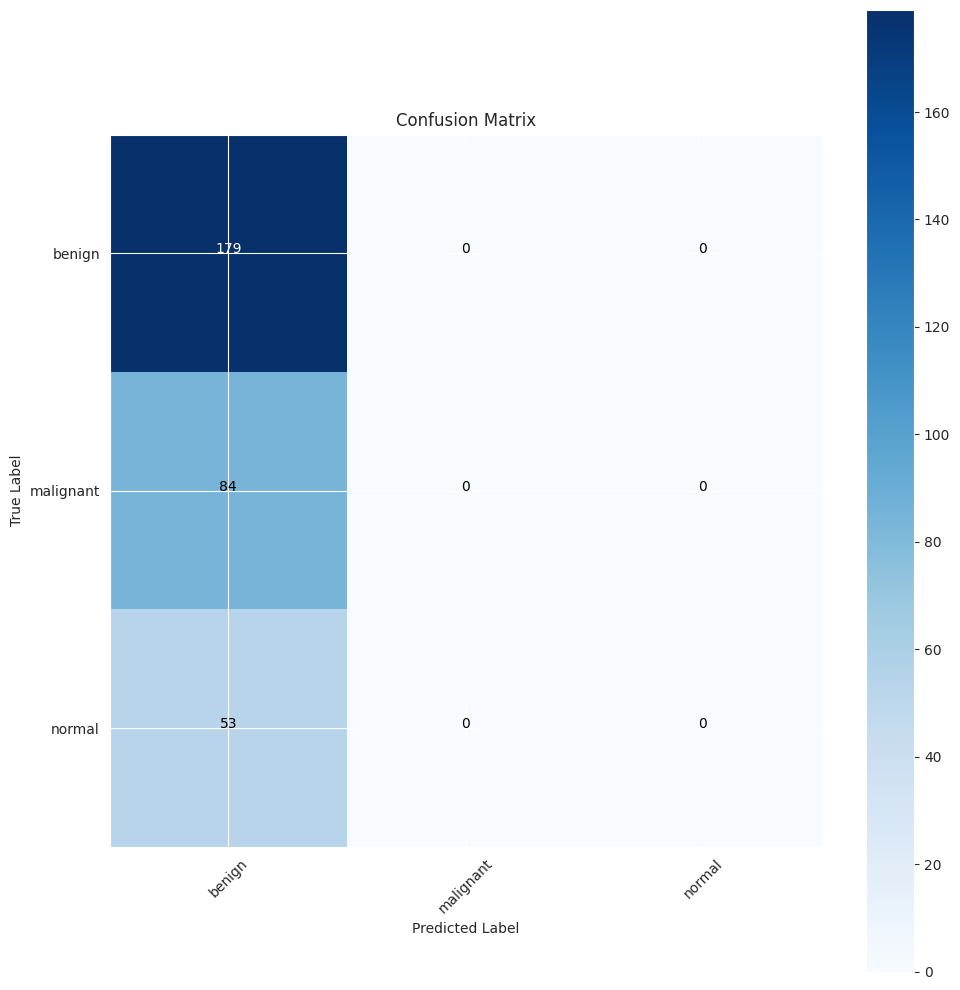

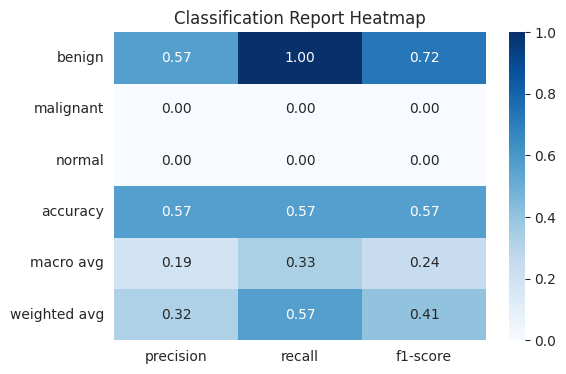

In [ ]:
# Generate class labels
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion Matrix
cm = confusion_matrix(test_gen.classes, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report Heatmap
classification_rep = classification_report(test_gen.classes, y_pred, target_names=classes, output_dict=True)
classification_df = pd.DataFrame(classification_rep).iloc[:-1, :].T  # Exclude 'accuracy'

plt.figure(figsize=(6, 4))
sns.heatmap(classification_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('Classification Report Heatmap')
plt.show()


In [ ]:


# Define directories for your datasets
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
augmented_data_dir = '/content/drive/MyDrive/Augmented_Dataset_BUSI_with_GT'

# Define the transformations (for example, resizing and tensor conversion)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to a consistent size (e.g., 224x224 for many models)
    transforms.ToTensor(),  # Convert images to PyTorch tensors
])

# Load the datasets using ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(augmented_data_dir, transform=transform),  # Assuming augmented data for training
    'test': datasets.ImageFolder(data_dir, transform=transform),  # Assuming original data for testing
}

# Create DataLoader for the test dataset
num_images_to_display = 15
test_dataloader = DataLoader(image_datasets['test'], batch_size=num_images_to_display, shuffle=True, num_workers=4)

# Example device setup (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Get a batch of test data
inputs, labels = next(iter(test_dataloader))

# Move inputs to the device
inputs = inputs.to(device)

# Convert images to grayscale (if inputs are in RGB format)
grayscale_images = inputs.cpu().numpy().mean(axis=1)  # Convert RGB to grayscale

# Assuming model_fineTuning is your pre-trained or fine-tuned model
with torch.no_grad():
    model_fineTuning.eval()  # Set the model to evaluation mode
    outputs = model_fineTuning(inputs)
    _, preds = torch.max(outputs, 1)  # Get the predicted class labels

# Plot the grayscale images with labels and predictions
plt.figure(figsize=(15, 20))  # Increase the height to accommodate 5 rows
for i in range(num_images_to_display):
    ax = plt.subplot(5, 3, i + 1)  # Adjust the layout to 5 rows by 3 columns
    ax.axis('off')
    ax.set_title(f'Actual: {image_datasets["test"].classes[labels[i]]}\nPredicted: {image_datasets["test"].classes[preds[i]]}')
    plt.imshow(grayscale_images[i], cmap='gray')  # Display the grayscale image

plt.show()


FileNotFoundError: Found no valid file for the classes Normal. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

      benign       0.57      1.00      0.72       179
   malignant       0.00      0.00      0.00        84
      normal       0.00      0.00      0.00        53

    accuracy                           0.57       316
   macro avg       0.19      0.33      0.24       316
weighted avg       0.32      0.57      0.41       316



In [ ]:
#Save the model
model.save('Model.h5')